In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import os

In [ ]:
ROOT_PATH = '/content/drive/MyDrive/VNL2025'
VIDEO_DIR = os.path.join(ROOT_PATH, 'videos')
FRAME_DIR = os.path.join(ROOT_PATH, 'frames')
AFFINED_DIR = os.path.join(ROOT_PATH, 'affined')
LABEL_PATH = os.path.join(AFFINED_DIR, 'label.csv')

# 初めてframeを切り取るときだけ実行
- ラベル保存用のファイル作成

In [ ]:
# # ラベル生成
# df_label = pd.DataFrame(columns = ['file_name', 'label', 'net_cord', 'score', None, None]) # 以前カラムを追加してfine-tuning前の画像の分析をしていた名残でNone, Noneカラムが2つ追加されている
# df_label.to_csv(LABEL_PATH, index=None) # 上書きするとそれまでのデータが失われるため注意

# dataset用の画像前処理
- `VIDEO_DIR`に動画を格納
- setterの背番号, 国籍を把握する
- 手動でフレーム数を調節しながら、ボールがセッターの手に触れた瞬間の画像を切り取る
- frame()では初めsave=Falseとして、適切なフレーム数を見つけたらTrueにする

## 関数の準備

In [ ]:
def frame(country, setter_no, target_frame, img_no, save=False):
    cap = cv2.VideoCapture(f'VIDEO_DIR/IMG_{img_no}.MOV')
    frame_num = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # # 特定のフレームだけ保存（例：60〜80フレーム目）
        # if 120 <= frame_num <= 121:
        #     cv2.imwrite(f'frame_{frame_num}.jpg', frame)

        # frame_num += 1
        if frame_num == target_frame:
            # OpenCVはBGR、matplotlibはRGBなので変換が必要
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            h, _, _ = frame_rgb.shape
            print(frame_rgb.shape)
            frame_rgb = frame_rgb[:-600, :, :]#h-600

            # matplotlibで表示
            plt.figure(figsize=(30, 10))
            plt.imshow(frame_rgb)
            plt.axis('off')
            plt.show()
            frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
            file_name = f'{country}_{setter_no}_{img_no}_{frame_num}.jpg'
            if save:
                output_path = f'FRAME_DIR/{file_name}'
                cv2.imwrite(output_path, frame_bgr)
            break

        frame_num += 1

    cap.release()
    return file_name

In [ ]:
def affine(file_name, upper_left, upper_right, under_left):
    output_path = f'FRAME_DIR/{file_name}'
    img = cv2.imread(output_path) #BGR
    h, w = img.shape[:2]
    dest = np.array([[200, 700], [900, 700], [200, 820]], np.float32)
    src = np.array([list(upper_left), list(upper_right), list(under_left)], np.float32)
    af = cv2.getAffineTransform(src, dest)
    converted = cv2.warpAffine(img, af, (w, h)) #BGR
    converted_rgb = cv2.cvtColor(converted, cv2.COLOR_RGB2BGR) # RGB
    plt.imshow(converted_rgb)
    plt.axis("off")
    plt.show()
    affined_path = f'AFFINED_DIR/{file_name}'
    cv2.imwrite(affined_path, converted) # #BGRのまま保存

In [ ]:
def add_label(file_name, label, src_save, score):
    """
    Args:
        file_name (str): frame()のreturn値
        label (str): トスが上がったポジション (left, middle, right, back_center, back_right, two)
        src_save (np.array): ネットの座標
        score (str): 点数に繋がったか (none: そのままラリーが続いた, score: 点数になった, miss: ミス, blocked: ブロックされて相手の点数になった)

    Returns:
        DataFrame: これまで保存したラベル
    """
    df_label = pd.read_csv(LABEL_PATH)
    # print(df_label.head())
    label_dic = {'left': 0, 'middle': 1, 'right': 2, 'back_center': 3, 'back_right': 4, 'two': 5}
    score_dic = {'none': 0, 'score': 1, 'miss': 2, 'blocked': 3}
    df_label.loc[len(df_label)] = [file_name, label_dic[label], src_save.tolist(), score_dic[score], None, None]
    df_label.to_csv(LABEL_PATH, index=None)
    return df_label

In [ ]:
def mod_label(file_name, column, value):
    """
    add_label()実行時に誤った値を入力してしまった時に実行する。
    複数項目間違えた場合は複数回実行する。

    Args:
        file_name (str): frame()のreturn値
        column (str): 訂正したい項目 (file_name, label, net_cord, score)
        value (str): 訂正後の値

    Returns:
        DataFrame: これまで保存したラベル
    """
    df_label = pd.read_csv(LABEL_PATH)
    label_dic = {'left': 0, 'middle': 1, 'right': 2, 'back_center': 3, 'back_right': 4, 'two': 5}
    score_dic = {'none': 0, 'score': 1, 'miss': 2, 'blocked': 3}
    id = df_label[df_label['file_name']==file_name].index
    if column=='label':
        value = label_dic[value]
    elif column=='score':
        value = score_dic[value]
    elif column=='net_cord':
        value = value.tolist()
    df_label.loc[id, column] = value
    df_label.to_csv(LABEL_PATH, index=None)
    return df_label

## ①動画をみて大体の秒数を定めて以下を実行していく

In [ ]:
(1*60+51) * 60 # 大体1sは60framesなため
# （100件超えているここでやめる）
# まだ未処理のframe↓
# 2m10s middle none
# 5s back_right score # 9s back_center score  # 31s back_center none # 52s back_center score（動画途中）

6660

In [ ]:
# setting
country = 'usa'
setter_no = 14
video_no = 5243
target_frame = 6672 # 1つ上で計算したframeから微調整

(1920, 1080, 3)


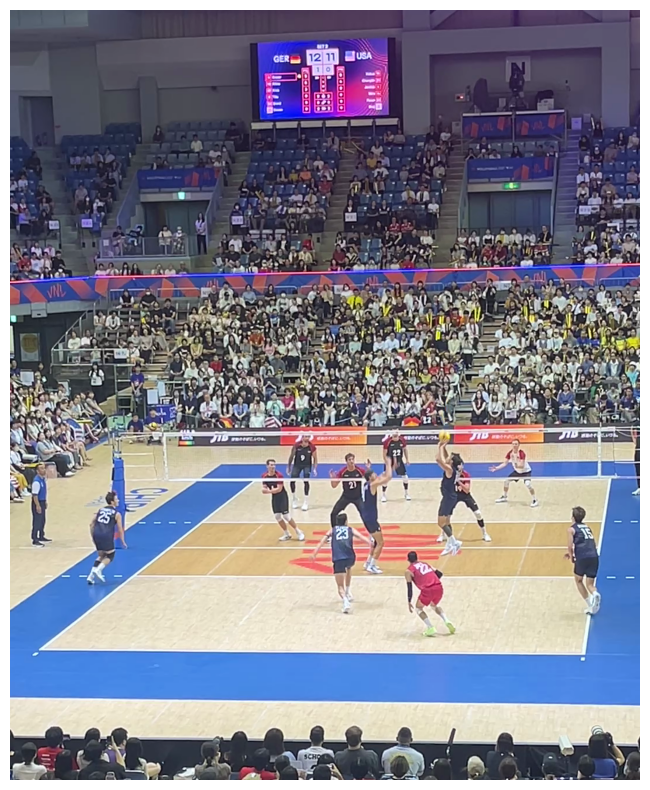

In [ ]:
file_name = frame(country, setter_no, target_frame, video_no, save=True) # save=Falseにしながら適切な箇所を決める

In [1382]:
file_name

'usa_14_5243_6672.jpg'

## ②ネットの座標を確認する（manually）

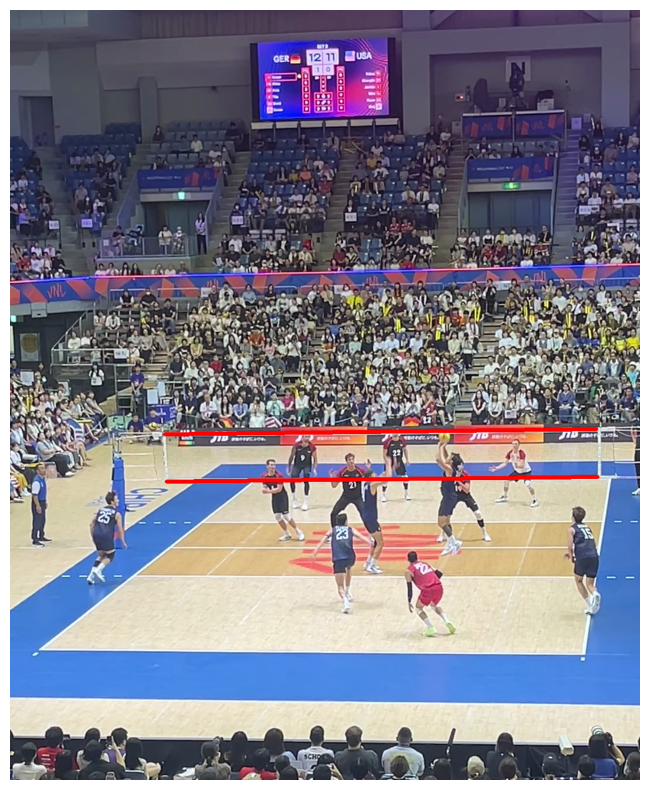

In [ ]:
# ネットの場所を特定
# 画像を読み込む（BGR -> RGB変換が必要）

img = cv2.imread(f'FRAME_DIR/{file_name}')
# 例：ネット上の座標
upper_left = (265, 727)
upper_right = (1005, 718)

# ネット下の座標（1点）
under_left = (268, 808)
under_right = (1007, 800)
src_save = np.array([list(upper_left), list(upper_right), list(under_left), list(under_right)], np.float32)

cv2.line(img, upper_left, upper_right, (0, 0, 255), 5)
cv2.line(img, under_left, under_right, (0, 0, 255), 5)

# 表示
plt.figure(figsize=(30, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [1394]:
# label_dic = {'left': 0, 'middle': 1, 'right': 2, 'back_center': 3, 'back_right': 4, 'two': 5}
# score_dic = {'none': 0, 'score': 1, 'miss': 2, 'blocked': 3}
add_label(file_name, 'left', src_save, 'score')

,file_name,label,net_cord,score,setter_skelton,all_skelton
0,tur_17_5202_240.jpg,2,"[[245.0, 1040.0], [973.0, 1040.0], [245.0, 111...",1,not detected,"[[[[640.439208984375, 793.9247436523438, 0.881..."
1,tur_17_5202_3501.jpg,1,"[[245.0, 1040.0], [973.0, 1040.0], [245.0, 111...",0,"[[[554.5629272460938, 729.3189697265625, 0.524...","[[[[120.01898193359375, 851.6826171875, 0.7051..."
2,tur_17_5202_3908.jpg,0,"[[267.0, 1000.0], [990.0, 990.0], [267.0, 1078...",1,not detected,"[[[[308.3571472167969, 897.5673217773438, 0.55..."
3,tur_17_5202_6765.jpg,0,"[[292.0, 733.0], [1022.0, 730.0], [294.0, 810....",0,not detected,"[[[[585.8861694335938, 931.0604858398438, 0.15..."
4,tur_17_5202_8758.jpg,3,"[[269.0, 710.0], [994.0, 707.0], [269.0, 788.0...",2,"[[[430.779052734375, 773.1727294921875, 0.3791...","[[[[121.95306396484375, 857.4791259765625, 0.1..."
...,...,...,...,...,...,...
95,usa_14_5243_466.jpg,2,"[[277.0, 801.0], [1021.0, 795.0], [278.0, 877....",3,NaN,NaN
96,usa_14_5243_2161.jpg,2,"[[253.0, 756.0], [998.0, 755.0], [255.0, 835.0...",1,NaN,NaN
97,usa_14_5243_4574.jpg,0,"[[265.0, 828.0], [1010.0, 815.0], [270.0, 902....",0,NaN,NaN
98,usa_14_5243_5065.jpg,0,"[[220.0, 850.0], [963.0, 835.0], [226.0, 930.0...",1,NaN,NaN


## ③もし修正があったら

In [ ]:
# mod_label(file_name, 'score','none')

# # 最終手段
# df_label = pd.read_csv(LABEL_PATH)
# df_label = df_label.drop(index=[46, 47, 48])
# # df_label.loc[40:50]
# # df_label = df_label.drop(columns=['left'])
# # df_label.tail()
# df_label.to_csv(LABEL_PATH, index=None)

## ④アフィン変換した画像を保存

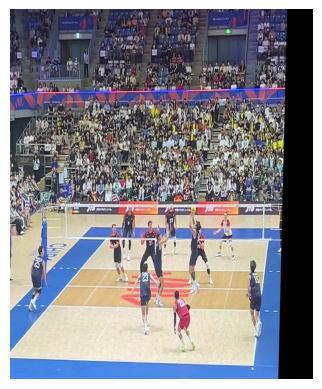

In [1396]:
affine(file_name, upper_left, upper_right, under_left)

In [1365]:
file_name

'usa_14_5243_5065.jpg'